Accuracy for K=1: 0.7778
Accuracy for K=3: 0.8056
Accuracy for K=5: 0.7222
Accuracy for K=7: 0.6944
Accuracy for K=9: 0.7222

Final Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        14
           1       0.75      0.64      0.69        14
           2       0.33      0.38      0.35         8

    accuracy                           0.69        36
   macro avg       0.65      0.65      0.65        36
weighted avg       0.70      0.69      0.70        36



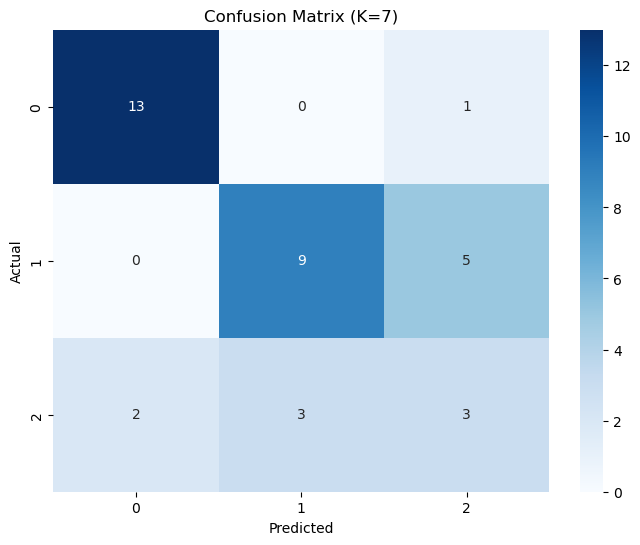

In [ ]:
# Task 3 – KNN Classifier

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# 1. Load and Preprocess [cite: 44]
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Compare different values of K [cite: 46]
k_values = [1, 3, 5, 7, 9]
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    scores.append(score)
    print(f"Accuracy for K={k}: {score:.4f}")

# 3. Evaluate the best model (using K=7) [cite: 45]
best_knn = KNeighborsClassifier(n_neighbors=7)
best_knn.fit(X_train, y_train)
final_preds = best_knn.predict(X_test)

print("\nFinal Classification Report:")
print(classification_report(y_test, final_preds))

# 4. Confusion Matrix Visualization [cite: 45]
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (K=7)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()